#*MAPAS TEMÁTICOS - USUARIOS DE TELÉFONOS MÓVILES *

In [128]:
import geopandas as gpd
linkGitHub= "https://github.com/DataEspacial/Evaluaci-n-Individual-1/raw/refs/heads/main/"
world_maps = "worldMaps.gpkg"

Identifico las capas que tiene el GDF, utilizo solo countries

In [129]:
gpd.list_layers(linkGitHub+world_maps)

,name,geometry_type
0,rivers,MultiLineString
1,cities,Point
2,countries,MultiPolygon


"countries" es la capa que quiero leer de GDF

In [130]:
countries=gpd.read_file(linkGitHub+world_maps, layer="countries")
countries

,COUNTRY,geometry
0,Aruba (Netherlands),"MULTIPOLYGON (((-69.88223 12.41111, -69.94695 ..."
1,Antigua and Barbuda,"MULTIPOLYGON (((-61.73889 17.54055, -61.75195 ..."
2,Afghanistan,"MULTIPOLYGON (((61.27656 35.60725, 61.29638 35..."
3,Algeria,"MULTIPOLYGON (((-5.15213 30.18047, -5.13917 30..."
4,Azerbaijan,"MULTIPOLYGON (((46.54037 38.87559, 46.49554 38..."
...,...,...
247,South Sudan,"MULTIPOLYGON (((34.21807 9.96458, 34.20722 9.9..."
248,Indonesia,"MULTIPOLYGON (((123.21846 -10.80917, 123.19832..."
249,East Timor,"MULTIPOLYGON (((124.41824 -9.3001, 124.40446 -..."
250,Curacao (Netherlands),"MULTIPOLYGON (((-68.96556 12.19889, -68.91196 ..."


Importo el Data Frame, leer la data que contiene el Panda

In [131]:
import pandas as pd
linkDF= "some_dataworld.csv"
dataworld = (linkGitHub+linkDF)
LeerData = pd.read_csv(dataworld)
LeerData

,Country,iso2,iso3,region,fragility,co2,sq_km,num_airports,population,mobiles
0,AFGHANISTAN,AF,AFG,SOUTH ASIA,105.0,7893000,652230,68,40121552,23000000
1,ALBANIA,AL,ALB,EUROPE,58.9,3794000,28748,3,3107100,2610000
2,ALGERIA,DZ,DZA,AFRICA,75.4,151633000,2381740,95,47022473,51500000
3,ANGOLA,AO,AGO,AFRICA,87.8,19362000,1246700,107,37202061,25700000
4,ANTIGUA AND BARBUDA,AG,ATG,CENTRAL AMERICA AND THE CARIBBEAN,54.4,729000,443,4,102634,184000
...,...,...,...,...,...,...,...,...,...,...
167,VENEZUELA,VE,VEN,SOUTH AMERICA,90.0,76730000,912050,509,31250306,18800000
168,VIETNAM,VN,VNM,EAST AND SOUTHEAST ASIA,66.1,249929000,331210,36,105758975,131000000
169,YEMEN,YE,YEM,MIDDLE EAST,113.5,10158000,527968,37,32140443,20000000
170,ZAMBIA,ZM,ZMB,AFRICA,85.7,6798000,752618,120,20799116,21200000


#Renombrar nombre de columnas del GDF Y DF




Reviso la asignación de la columna de "country", no son iguales-renombrar

In [132]:
countries.COUNTRY.head()

,COUNTRY
0,Aruba (Netherlands)
1,Antigua and Barbuda
2,Afghanistan
3,Algeria
4,Azerbaijan


In [133]:
LeerData.Country.head()

,Country
0,AFGHANISTAN
1,ALBANIA
2,ALGERIA
3,ANGOLA
4,ANTIGUA AND BARBUDA


Se renombra la columna del GDF a "country" para que ambas columnas sean iguales, se guarda. Luego selecciono la columna "country" y convierto todo a Mayúscula. Por último verifico los paises que tienen información tanto el el GDF como en el DF


In [134]:
countries.rename(columns={'COUNTRY': 'Country'}, inplace=True)

countries['Country'] = countries['Country'].str.upper()
LeerData['Country'] = LeerData['Country'].str.upper()

onlyDF = set(LeerData['Country']) - set(countries['Country'])
onlyGDF = set(countries['Country']) - set(LeerData['Country'])



No se encontro ninguna similitud entre el GDF y DF, para los datos

In [135]:
onlyDF

{'BAHAMAS (THE)',
 'BOLIVIA (PLURINATIONAL STATE OF)',
 'BRUNEI DARUSSALAM',
 'CABO VERDE',
 'CENTRAL AFRICAN REPUBLIC (THE)',
 'COMOROS (THE)',
 'CONGO (THE DEMOCRATIC REPUBLIC OF THE)',
 'CONGO (THE)',
 "CÔTE D'IVOIRE",
 'DOMINICAN REPUBLIC (THE)',
 'ESWATINI',
 'GAMBIA (THE)',
 'IRAN (ISLAMIC REPUBLIC OF)',
 'KOREA (THE REPUBLIC OF)',
 "LAO PEOPLE'S DEMOCRATIC REPUBLIC (THE)",
 'MICRONESIA (FEDERATED STATES OF)',
 'MOLDOVA (THE REPUBLIC OF)',
 'NETHERLANDS (THE)',
 'NIGER (THE)',
 'NORTH MACEDONIA',
 'NORTHERN MARIANA ISLANDS (THE)',
 'PHILIPPINES (THE)',
 'RUSSIAN FEDERATION (THE)',
 'SAMOA',
 'SUDAN (THE)',
 'TANZANIA, THE UNITED REPUBLIC OF',
 'TIMOR-LESTE',
 'UNITED ARAB EMIRATES (THE)',
 'UNITED KINGDOM OF GREAT BRITAIN AND NORTHERN IRELAND (THE)',
 'UNITED STATES OF AMERICA (THE)'}

#Unión del GeodataFrame y del DataFrame

Fuzzy matching para detectar las coincidencias más parecidas
y también los nombres que no siempre coinciden de forma exacta

In [136]:
!pip install thefuzz
from thefuzz.process import extractOne as best
[(country, best(country, onlyGDF)) for country in onlyDF]

[('NORTH MACEDONIA', ('MACEDONIA', 90)),
 ('UNITED STATES OF AMERICA (THE)', ('UNITED STATES', 90)),
 ('DOMINICAN REPUBLIC (THE)', ('DOMINICAN REPUBLIC', 95)),
 ('NETHERLANDS (THE)', ('NETHERLANDS', 95)),
 ('MICRONESIA (FEDERATED STATES OF)', ('FEDERATED STATES OF MICRONESIA', 95)),
 ('UNITED KINGDOM OF GREAT BRITAIN AND NORTHERN IRELAND (THE)',
  ('UNITED KINGDOM', 90)),
 ('MOLDOVA (THE REPUBLIC OF)', ('MOLDOVA', 90)),
 ('NIGER (THE)', ('NIGER', 90)),
 ('COMOROS (THE)', ('COMOROS', 90)),
 ('IRAN (ISLAMIC REPUBLIC OF)', ('IRAN', 90)),
 ('KOREA (THE REPUBLIC OF)', ('SOUTH KOREA', 86)),
 ('BRUNEI DARUSSALAM', ('BRUNEI', 90)),
 ('GAMBIA (THE)', ('GAMBIA', 90)),
 ('RUSSIAN FEDERATION (THE)', ('RUSSIA', 90)),
 ('BAHAMAS (THE)', ('BAHAMAS', 90)),
 ('SAMOA', ('AMERICAN SAMOA (US)', 90)),
 ('BOLIVIA (PLURINATIONAL STATE OF)', ('BOLIVIA', 90)),
 ('PHILIPPINES (THE)', ('PHILIPPINES', 95)),
 ('CABO VERDE', ('CAPE VERDE', 80)),
 ('CONGO (THE)', ('CONGO', 90)),
 ('CONGO (THE DEMOCRATIC REPUBLIC OF 

Estos son los 4 paises que no tienen coincidencia

In [137]:
countries.Country[countries.Country.str.contains('BAHAMA|DOMINIC|BOLIV|UNITED STATES')]

,Country
20,BAHAMAS
24,BOLIVIA
57,DOMINICA
59,DOMINICAN REPUBLIC
229,UNITED STATES


Algunos países usan nombres oficiales largos en el DF, pero nombres cortos en el GDF. Se encontraron estos 4 paises que diferian en el caso estudiado.

In [138]:
manualChanges = {
    'BAHAMAS (THE)': 'BAHAMAS',
    'DOMINICAN REPUBLIC (THE)': 'DOMINICAN REPUBLIC',
    'UNITED STATES OF AMERICA (THE)': 'UNITED STATES',
    'BOLIVIA (PLURINATIONAL STATE OF)': 'BOLIVIA',
}

LeerData.replace(to_replace={'Country': manualChanges}, inplace=True)

Se verificó que ya no hay diferencias significables con los paises de Sur, Norte, Centroamérica y El Caribe.

In [139]:
onlyDF = set(LeerData.Country) - set(countries.Country)
onlyGDF = set(countries.Country) - set(LeerData.Country)
print(onlyDF)

{'NORTH MACEDONIA', 'NETHERLANDS (THE)', 'MICRONESIA (FEDERATED STATES OF)', 'UNITED KINGDOM OF GREAT BRITAIN AND NORTHERN IRELAND (THE)', 'MOLDOVA (THE REPUBLIC OF)', 'NIGER (THE)', 'COMOROS (THE)', 'IRAN (ISLAMIC REPUBLIC OF)', 'KOREA (THE REPUBLIC OF)', 'BRUNEI DARUSSALAM', 'GAMBIA (THE)', 'RUSSIAN FEDERATION (THE)', 'SAMOA', 'PHILIPPINES (THE)', 'CABO VERDE', 'CONGO (THE)', 'CONGO (THE DEMOCRATIC REPUBLIC OF THE)', 'UNITED ARAB EMIRATES (THE)', "CÔTE D'IVOIRE", 'SUDAN (THE)', 'ESWATINI', "LAO PEOPLE'S DEMOCRATIC REPUBLIC (THE)", 'CENTRAL AFRICAN REPUBLIC (THE)', 'TIMOR-LESTE', 'NORTHERN MARIANA ISLANDS (THE)', 'TANZANIA, THE UNITED REPUBLIC OF'}


#EL MERGE

Aquí countries es el GDF (con geometría) y LeerData es el DF (con mobiles, population, region, otros). El resultado theMapAndData ya tiene ambas juntas.

In [140]:
theMapAndData = countries.merge(LeerData, on='Country')
theMapAndData.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Country       146 non-null    object  
 1   geometry      146 non-null    geometry
 2   iso2          145 non-null    object  
 3   iso3          146 non-null    object  
 4   region        146 non-null    object  
 5   fragility     146 non-null    float64 
 6   co2           146 non-null    int64   
 7   sq_km         146 non-null    int64   
 8   num_airports  146 non-null    int64   
 9   population    146 non-null    int64   
 10  mobiles       146 non-null    int64   
dtypes: float64(1), geometry(1), int64(5), object(4)
memory usage: 12.7+ KB


In [141]:
theMapAndData.to_file("worldindicators.json")

#

# Thematics: the DDM (Dot Density Map)

Se tiene el mapa de todo el mundo, solo quiero Sur, Norte, Centroamérica y El Caribe

In [142]:
theMapAndData.region.value_counts()

,count
region,
AFRICA,41
EUROPE,33
CENTRAL AMERICA AND THE CARIBBEAN,16
MIDDLE EAST,14
SOUTH AMERICA,12
EAST AND SOUTHEAST ASIA,10
SOUTH ASIA,8
CENTRAL ASIA,5
AUSTRALIA AND OCEANIA,4


Quedo solo con los países de nuestra región de interés: Norte, Centro América y el Caribe, y Sudamérica.

In [143]:
regionesAmerica = ['NORTH AMERICA', 'CENTRAL AMERICA AND THE CARIBBEAN', 'SOUTH AMERICA']
America = theMapAndData[theMapAndData.region.isin(regionesAmerica)]

El .plot() muestra el mapa con solo el continente americano (Norteamérica, Centroamérica, el Caribe y Sudamérica)

<Axes: >

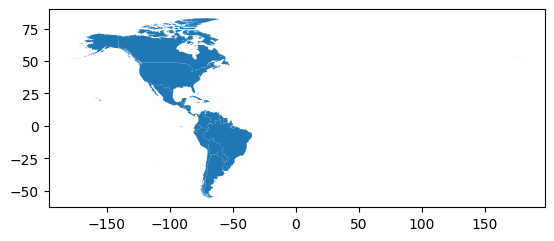

In [144]:
America.region.value_counts()
America.plot()

Preprocesamiento: agregación

In [145]:
justDots = America.copy()
dot_value = 150000
justDots['num_dots'] = (justDots['mobiles'] / dot_value).astype(int)

generar las ubicaciones aleatorias de los puntos:

In [146]:
justDots = justDots.sample_points(size=justDots['num_dots']).explode(index_parts=True)
justDots

0    0       POINT (-61.77607 17.61893)
7    0      POINT (-58.58123 -28.51935)
     1      POINT (-65.52283 -26.18549)
     2      POINT (-68.72135 -29.98338)
     3      POINT (-69.14395 -37.18968)
                       ...             
138  120      POINT (-67.02656 8.90381)
     121      POINT (-64.88668 9.83045)
     122      POINT (-68.49603 7.41522)
     123      POINT (-64.76482 3.66051)
     124       POINT (-62.48044 8.2634)
Name: sampled_points, Length: 7664, dtype: geometry

Preprocesamiento: construyendo el GDF desde la GeoSeries

In [147]:
justDots.reset_index(drop=True, inplace=True)
America_dots = gpd.GeoDataFrame(geometry=justDots)
America_dots.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 7664 entries, 0 to 7663
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   geometry  7664 non-null   geometry
dtypes: geometry(1)
memory usage: 60.0 KB


Se dibuja los polígonos como base y los puntos como capa superior

<Axes: >

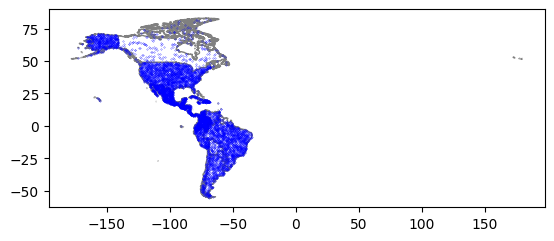

In [148]:
base = America.plot(facecolor="white", edgecolor='grey')
America_dots.plot(markersize=0.04, color='blue', ax=base)

Celda 2 mismo mapa, pero ahora con la proyección correcta para no distorsionar áreas

<Axes: >

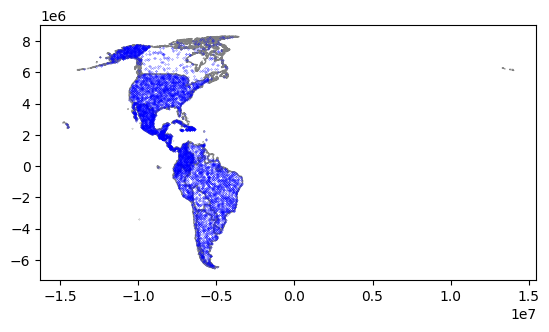

In [149]:
base=America.to_crs(8857).plot(facecolor="white",
                              edgecolor='grey')
America_dots.to_crs(8857).plot(markersize=0.04, color='blue',ax=base)

se guardan la versión ya reproyectada en variables nuevas

In [150]:
America_8857=America.to_crs(8857)
America_dots_8857=America_dots.to_crs(8857)

#Temática: el PSM (Mapa de Símbolos Proporcionales)


Preprocesamiento: GDF de centroides
Ubicación de un símbolo del centroide del polígono.

In [151]:
America_8857_centroids = America_8857.copy()
America_8857_centroids['geometry'] = America_8857_centroids['geometry'].centroid

Tamaño del símbolo (según mobiles)

In [152]:
America_8857_centroids['size'] = America_8857_centroids['mobiles'].apply(lambda x: x**0.5/100)

Plot básico (Mapa de simbolos proprcionales)

<Axes: >

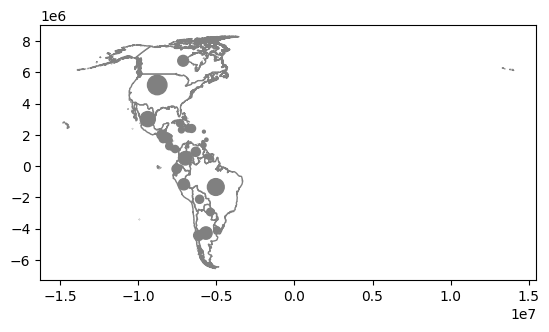

In [153]:
base=America_8857.plot(facecolor="white",
                      edgecolor='grey')
America_8857_centroids.plot(
    ax=base,
    markersize=America_8857_centroids['size'],
    color='grey'
)

Corregcción del problema de las islas
Con centroide, un país con archipiélago ( Bahamas) puede terminar con su punto en el mar. Para evitar eso, usamos representative_point()

In [154]:
America_8857_centroids["geometry"] = America_8857.representative_point()

Este último plot ya con representative_point()

<Axes: >

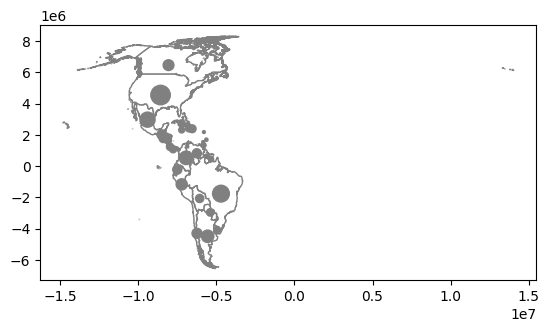

In [155]:
base=America_8857.plot(facecolor="white",
                      edgecolor='grey')
America_8857_centroids.plot(
    ax=base,
    markersize=America_8857_centroids['size'],
    color='grey'
)


Generar el boxplot y detectar outliers



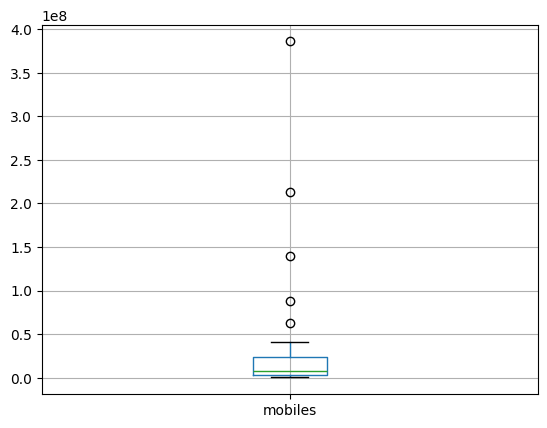

In [156]:
boxplotInfo = America_8857_centroids.boxplot(column='mobiles', return_type="dict")

Extraer los valores atípicos (los puntitos que salen fuera de los "bigotes" del boxplot)

In [157]:
outliers = boxplotInfo['fliers'][0].get_ydata()
outliers

array([62700000, 213000000, 87400000, 140000000, 386000000], dtype=object)

Ver cuáles son esos países

In [158]:
America_8857_centroids[America_8857_centroids.mobiles.isin(outliers)]

,Country,geometry,iso2,iso3,region,fragility,co2,sq_km,num_airports,population,mobiles,size
7,ARGENTINA,POINT (-5553772.712 -4493827.822),AR,ARG,SOUTH AMERICA,46.0,193205000,2780400,764,46994384,62700000,79.183332
22,BRAZIL,POINT (-4700709.502 -1764170.762),BR,BRA,SOUTH AMERICA,71.8,456670000,8515770,5297,220051512,213000000,145.945195
33,COLOMBIA,POINT (-6936232.356 525486.665),CO,COL,SOUTH AMERICA,75.7,81007000,1138910,661,49588357,87400000,93.487967
93,MEXICO,POINT (-9402396.302 2972427.316),MX,MEX,NORTH AMERICA,69.7,463739000,1964375,1580,130739927,140000000,118.321596
134,UNITED STATES,POINT (-8568177.661 4547618.41),US,USA,NORTH AMERICA,38.0,5144361000,9833517,16116,341963408,386000000,196.468827


Se creó una columna de bandera (flag) de outlier

In [159]:
America_8857_centroids['mobiles_outlier'] = America_8857_centroids.mobiles.isin(outliers)*1
America_8857_centroids

,Country,geometry,iso2,iso3,region,fragility,co2,sq_km,num_airports,population,mobiles,size,mobiles_outlier
0,ANTIGUA AND BARBUDA,POINT (-5794568.997 2176408.939),AG,ATG,CENTRAL AMERICA AND THE CARIBBEAN,54.4,729000,443,4,102634,184000,4.289522,0
7,ARGENTINA,POINT (-5553772.712 -4493827.822),AR,ARG,SOUTH AMERICA,46.0,193205000,2780400,764,46994384,62700000,79.183332,1
11,BARBADOS,POINT (-5635598.674 1688332.479),BB,BRB,CENTRAL AMERICA AND THE CARIBBEAN,48.0,1703000,430,1,304139,323000,5.683309,0
14,BAHAMAS,POINT (-6800793.456 2682348.628),BS,BHS,CENTRAL AMERICA AND THE CARIBBEAN,48.8,3984000,13880,54,410862,400000,6.324555,0
16,BELIZE,POINT (-8318589.082 2194756.836),BZ,BLZ,CENTRAL AMERICA AND THE CARIBBEAN,62.5,541000,22966,27,415789,264000,5.138093,0
18,BOLIVIA,POINT (-6065512.507 -2073238.575),BO,BOL,SOUTH AMERICA,72.9,17786000,1098581,201,12311974,12000000,34.641016,0
22,BRAZIL,POINT (-4700709.502 -1764170.762),BR,BRA,SOUTH AMERICA,71.8,456670000,8515770,5297,220051512,213000000,145.945195,1
26,CANADA,POINT (-8057335.615 6460418.072),CA,CAN,NORTH AMERICA,20.0,612084000,9984670,1459,38794813,36500000,60.415230,0
31,CHILE,POINT (-6234313.161 -4304799.911),CL,CHL,SOUTH AMERICA,38.9,88333000,756102,379,18664652,26700000,51.672043,0
33,COLOMBIA,POINT (-6936232.356 525486.665),CO,COL,SOUTH AMERICA,75.7,81007000,1138910,661,49588357,87400000,93.487967,1


Usar ese flag para colorear el mapa

<Axes: >

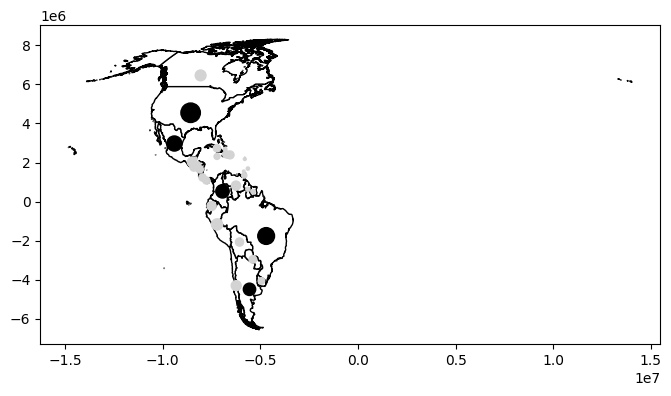

In [160]:
base = America_8857.plot(color='white', edgecolor='black', figsize=(8,8))

mapcolor = {1: 'black', 0: 'lightgrey'}

America_8857_centroids.plot(
    ax=base,
    markersize=America_8857_centroids['size'],
    color=America_8857_centroids['mobiles_outlier'].map(mapcolor)
)

# Thematics: Choropleths

Calcular la variable normalizada


In [161]:
America_8857['mobiles_rate'] = America_8857.mobiles / America_8857.population

Preprocesamiento: Discretización. Importar librerias

In [162]:
import mapclassify
import numpy as np

np.random.seed(12345)

K = 5
theVar = America_8857['mobiles_rate']

ei5 = mapclassify.EqualInterval(theVar, k=K)
msd = mapclassify.StdMean(theVar)
q5 = mapclassify.Quantiles(theVar, k=K)
mb5 = mapclassify.MaximumBreaks(theVar, k=K)
ht = mapclassify.HeadTailBreaks(theVar)
fj5 = mapclassify.FisherJenks(theVar, k=K)
jc5 = mapclassify.JenksCaspall(theVar, k=K)
mp5 = mapclassify.MaxP(theVar, k=K)

comparar clasificadores

<Axes: ylabel='Classifier'>

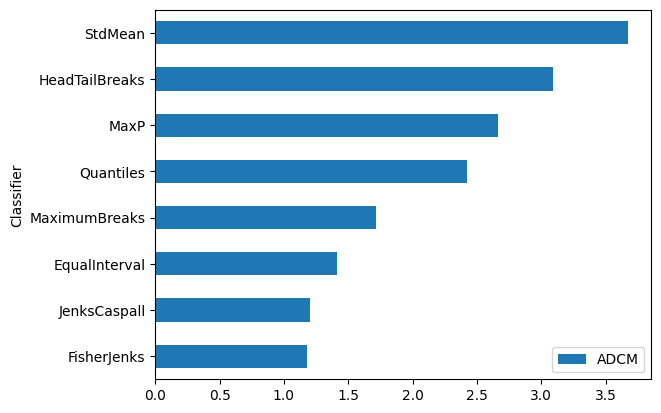

In [163]:
class5 = ei5, msd, q5, mb5, ht, fj5, jc5, mp5
fits = np.array([c.adcm for c in class5])

adcms = pd.DataFrame(fits)
adcms['classifier'] = [c.name for c in class5]
adcms.columns = ['ADCM', 'Classifier']

adcms.sort_values('ADCM').plot.barh(x='Classifier')

se guarda la mejor clasificación,  FisherJenks

In [164]:
America_8857['mobiles_rate_FJ5'] = fj5.yb

newLabelsForLevels = {0:"0_VeryLow", 1:"1_Low", 2:"2_Middle", 3:"3_High", 4:"4_VeryHigh"}
America_8857['mobiles_rate_FJ5_cat'] = America_8857['mobiles_rate_FJ5'].replace(newLabelsForLevels)

Ploteo del mapa final, este sí es el choropleto

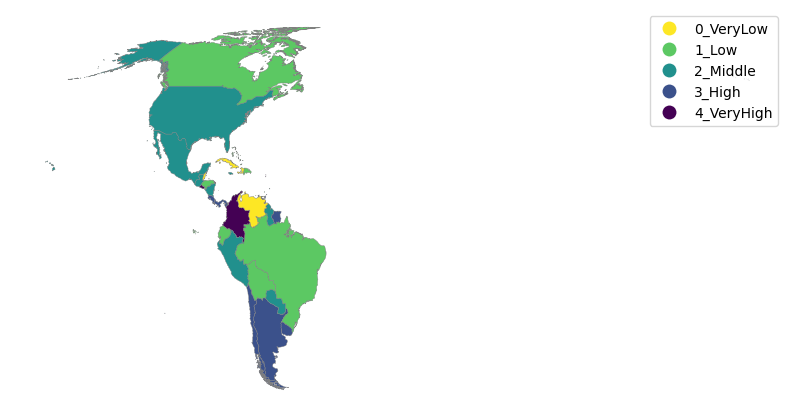

In [165]:
import matplotlib.pyplot as plt

f, ax = plt.subplots(1, figsize=(10, 10))
America_8857.plot(column='mobiles_rate_FJ5_cat',
                 cmap='viridis_r',
                 categorical=True,
                 edgecolor='grey',
                 linewidth=0.3,
                 legend=True,
                 ax=ax)

ax.set_axis_off()

#Guardar para crear un dashboard

In [166]:

geodataframe_list = [var for var in globals() if isinstance(globals()[var], gpd.GeoDataFrame)]

print("Lista de GeoDataFrames en memoria:")
for name in geodataframe_list:
    print(name)

Lista de GeoDataFrames en memoria:
___
countries
gdf
_21
_22
_24
_36
gdf_merged
gdf_americas
_73
theMapAndData
America
America_dots
America_8857
America_dots_8857
America_8857_centroids
_114
_115
_130
_158
_159


Información de lo que se necesita para los 3 mapas realizados

In [167]:
# para choropleth y mapa base
America_8857.info()

# para el DDM
America_dots_8857.info()

# para el PSM
America_8857_centroids.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 31 entries, 0 to 138
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Country               31 non-null     object  
 1   geometry              31 non-null     geometry
 2   iso2                  31 non-null     object  
 3   iso3                  31 non-null     object  
 4   region                31 non-null     object  
 5   fragility             31 non-null     float64 
 6   co2                   31 non-null     int64   
 7   sq_km                 31 non-null     int64   
 8   num_airports          31 non-null     int64   
 9   population            31 non-null     int64   
 10  mobiles               31 non-null     int64   
 11  mobiles_rate          31 non-null     float64 
 12  mobiles_rate_FJ5      31 non-null     int64   
 13  mobiles_rate_FJ5_cat  31 non-null     object  
dtypes: float64(2), geometry(1), int64(6), object(5)
memory u

Guardo cada uno en un archivo  para exportarlos

In [168]:
America_8857.to_file("america_choropleth.json")
America_dots_8857.to_file("america_ddm_dots.json")
America_8857_centroids.to_file("america_psm_centroids.json")